#### I : Učitavanje skupa podataka

<small> 

Za potrebe projekta korišćen je **DIV2K** skup podataka, koji je namenjen zadacima super-rezolucije slika. 

- DIV2K skup podataka sadrži $1.000$ **visokorezolucionih fotografija**, od kojih je $800$ namenjeno za **trening** modela (*DIV2K_train_HR*), a $200$ za **validaciju** (*DIV2K_val_HR*). 
- Fotografije su različitih sadržaja i scena i predstavljaju prirodne slike visoke rezolucije.

In [6]:
import os

train_path = "./DIV2K_train_HR"
val_path = "./DIV2K_valid_HR"

train_images = os.listdir(train_path)
val_images = os.listdir(val_path)

print("Broj trening slika:", len(train_images))
print("Broj validacionih slika:", len(val_images))

Broj trening slika: 800
Broj validacionih slika: 100


#### II : Analiza dimenzija slika iz skupa podataka

<small>

Za svaku sliku iz trening i validacionog skupa određene su širina i visina, a zatim su izračunate njihove minimalne, maksimalne i prosečne vrednosti.

- Ova analiza omogućava **uvid u strukturu** i **karakteristike** skupa podataka, kao i proveru da li slike imaju jednake ili različite dimenzije. 
- Informacija o dimenzijama je značajna za dalju pripremu podataka, jer je za treniranje konvolutivne neuronske mreže potrebno prilagoditi slike odgovarajućem formatu i dimenzijama.
- **Histogramima** su prikazane **raspodele širina** i **visina slika** u trening i validacionom skupu radi lakšeg uočavanja njihovog **raspona** i **učestalosti**.

</small>

                             TRENING SKUP     VALIDACIONI SKUP
-----------------------------------------------------------------
Minimalna širina:                 1116px              1356px
Maksimalna širina:                2040px              2040px
Prosečna širina:                  1971px              1978px

Minimalna visina:                  648px               816px
Maksimalna visina:                2040px              2040px
Prosečna visina:                  1435px              1450px


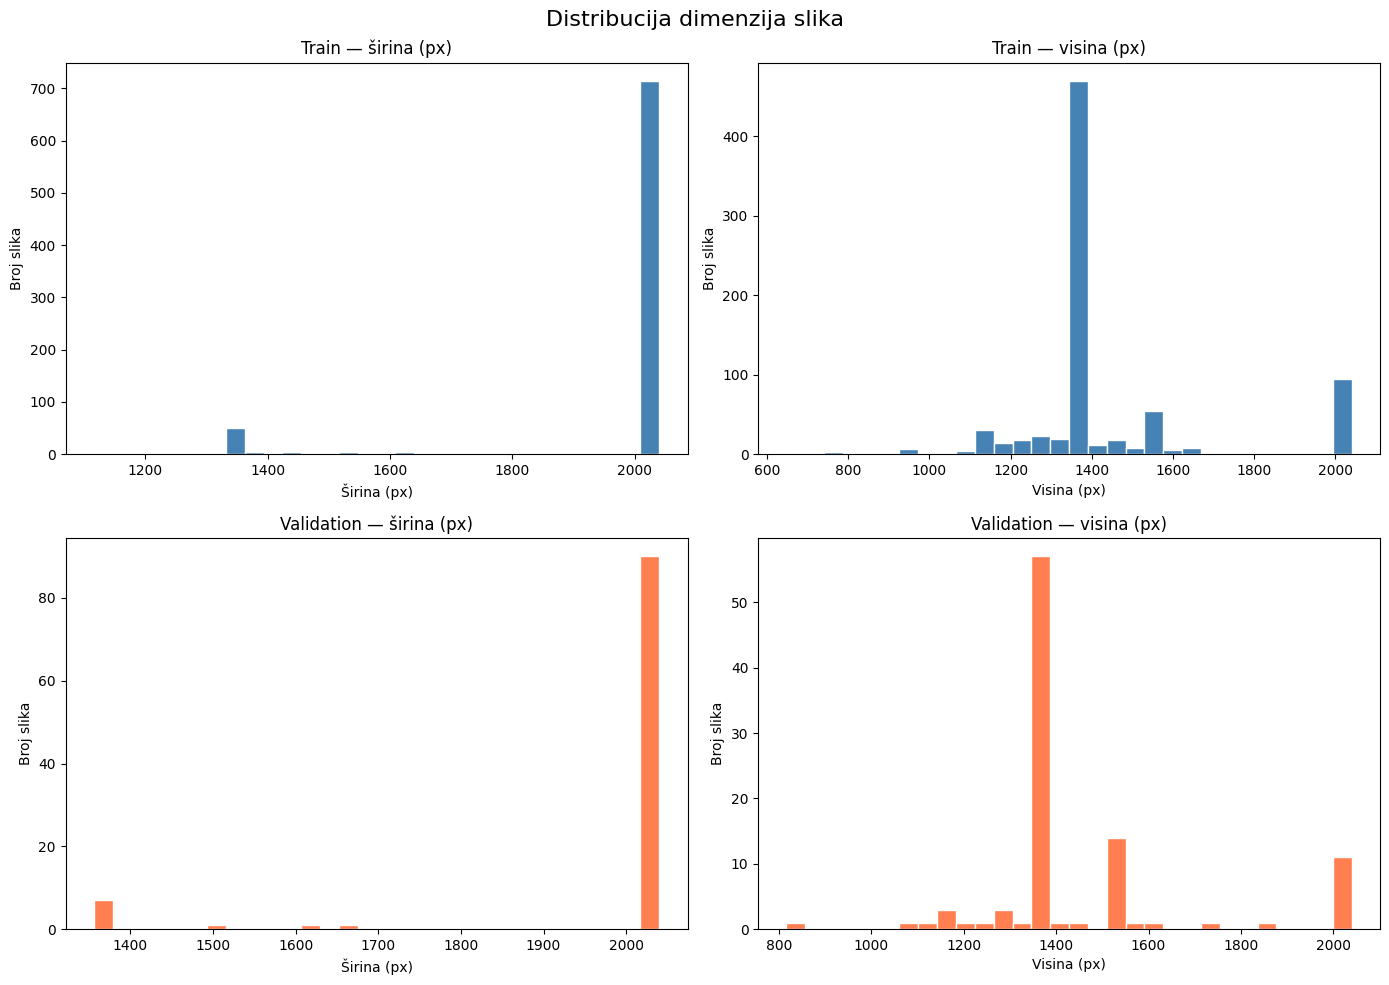

In [14]:
from PIL import Image
import matplotlib.pyplot as plt


from PIL import Image
import os

# Train skup
train_widths, train_heights = [], []

for fname in train_images:
    img = Image.open(os.path.join(train_path, fname))
    w, h = img.size
    train_widths.append(w)
    train_heights.append(h)

# Validation skup
val_widths, val_heights = [], []

for fname in val_images:
    img = Image.open(os.path.join(val_path, fname))
    w, h = img.size
    val_widths.append(w)
    val_heights.append(h)

print(f"{'':25} {'TRENING SKUP':>15} {'VALIDACIONI SKUP':>20}")
print("-" * 65)
print(f"{'Minimalna širina:':25} {min(train_widths):>12}px {min(val_widths):>17}px")
print(f"{'Maksimalna širina:':25} {max(train_widths):>12}px {max(val_widths):>17}px")
print(f"{'Prosečna širina:':25} {int(sum(train_widths)/len(train_widths)):>12}px {int(sum(val_widths)/len(val_widths)):>17}px")
print()
print(f"{'Minimalna visina:':25} {min(train_heights):>12}px {min(val_heights):>17}px")
print(f"{'Maksimalna visina:':25} {max(train_heights):>12}px {max(val_heights):>17}px")
print(f"{'Prosečna visina:':25} {int(sum(train_heights)/len(train_heights)):>12}px {int(sum(val_heights)/len(val_heights)):>17}px")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribucija dimenzija slika', fontsize=16)

# Train širine
axes[0, 0].hist(train_widths, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Train — širina (px)')
axes[0, 0].set_xlabel('Širina (px)')
axes[0, 0].set_ylabel('Broj slika')

# Train visine
axes[0, 1].hist(train_heights, bins=30, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Train — visina (px)')
axes[0, 1].set_xlabel('Visina (px)')
axes[0, 1].set_ylabel('Broj slika')

# Valid širine
axes[1, 0].hist(val_widths, bins=30, color='coral', edgecolor='white')
axes[1, 0].set_title('Validation — širina (px)')
axes[1, 0].set_xlabel('Širina (px)')
axes[1, 0].set_ylabel('Broj slika')

# Valid visine
axes[1, 1].hist(val_heights, bins=30, color='coral', edgecolor='white')
axes[1, 1].set_title('Validation — visina (px)')
axes[1, 1].set_xlabel('Visina (px)')
axes[1, 1].set_ylabel('Broj slika')

plt.tight_layout()
plt.show()

<small>

> Na osnovu dobijenih rezultata može se zaključiti da slike u **DIV2K** skupu podataka **nemaju uniformne dimenzije**.<br>
> Može se uočiti da su **prosečne dimenzije** trening i validacionog skupa veoma **slične**, što ukazuje na njihovu međusobnu konzistentnost.<br>

> **Različite** i **velike dimenzije slika** zahtevaju njihovu **dodatnu obradu** pre treniranja modela, odnosno prilagođavanje na uniformnu dimenziju pogodnu za **ulaz** u konvolutivnu neuronsku mrežu.

</small>

#### III : Prikaz primera slika iz skupa podataka

<small>

Za vizuelni uvid u sadržaj skupa podataka, prikazano je šest nasumično odabranih slika iz **trening** skupa.

- Prikazane slike predstavljaju **različite sadržaje** i **scene** iz trening skupa i potvrđuju **raznovrsnost podataka** koji će se koristiti za treniranje modela.

</small>

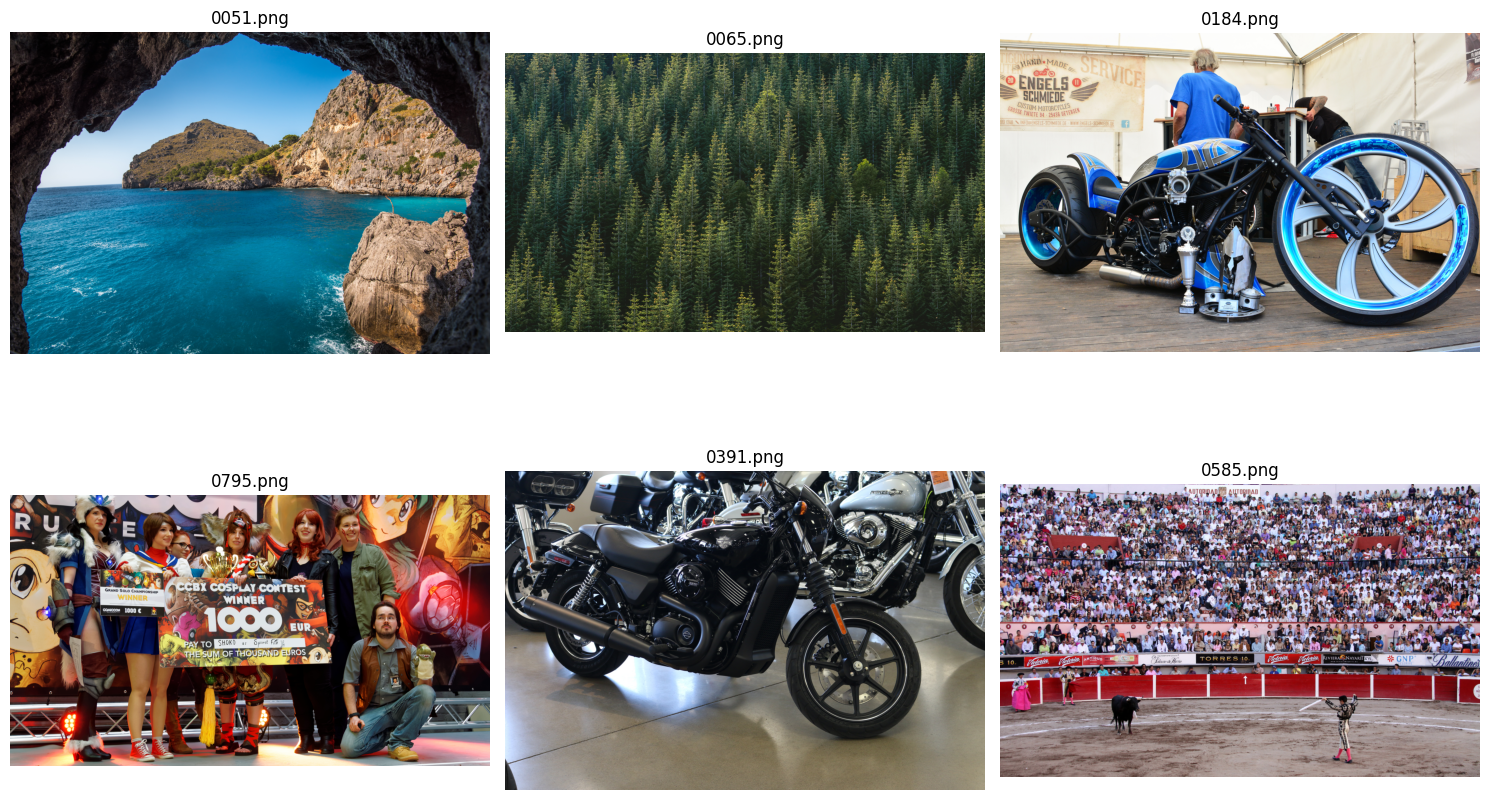

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

sample_images = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, fname in zip(axes.flat, sample_images):
    img = Image.open(os.path.join(train_path, fname))
    
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### IV : Provera formata i broja kanala slika iz skupa podataka

<small> 

Proverom **formata** i **broja kanala** utvrđeno je da su sve slike iz trening i validacionog skupa u **RGB formatu** i da svaka slika sadrži **tri kanala boja** (**R**, **G** i **B**). 

- Ovakav format omogućava **očuvanje informacija o boji i strukturi originalnih fotografija**, što je značajno za zadatak rekonstrukcije i povećanja rezolucije slike. 

</small>

In [20]:
from PIL import Image
import os
from collections import Counter

train_modes = Counter()
train_channels = Counter()

for fname in train_images:
    img = Image.open(os.path.join(train_path, fname))
    
    train_modes[img.mode] += 1
    train_channels[len(img.getbands())] += 1

val_modes = Counter()
val_channels = Counter()

for fname in val_images:
    img = Image.open(os.path.join(val_path, fname))
    
    val_modes[img.mode] += 1
    val_channels[len(img.getbands())] += 1

print("--- TRENING SKUP ---")
print("Format:", train_modes)
print("Broj kanala:", train_channels)

print("\n--- VALIDACIONI SKUP ---")
print("Format:", val_modes)
print("Broj kanala:", val_channels)

--- TRENING SKUP ---
Format: Counter({'RGB': 800})
Broj kanala: Counter({3: 800})

--- VALIDACIONI SKUP ---
Format: Counter({'RGB': 100})
Broj kanala: Counter({3: 100})


<small>

> Dobijeni rezultat potvrđuje da **nije potrebna dodatna konverzija formata slika** pre njihove dalje obrade i pripreme za treniranje konvolutivne neuronske mreže.

</small>

#### V : Provera kvaliteta slika iz skupa podataka

<small>

Pre dalje obrade izvršena je provera **ispravnosti fajlova** i njihovih formata kako bi se utvrdilo da li postoje **oštećene** ili **nečitljive slike** i koje **ekstenzije** se koriste u skupu podataka.

</small>

In [23]:
# Provera oštećenih slika

def check_images(path, images):
    corrupted = []

    for fname in images:
        try:
            img = Image.open(os.path.join(path, fname))
            img.verify()
        except:
            corrupted.append(fname)

    return corrupted


train_corrupted = check_images(train_path, train_images)
val_corrupted = check_images(val_path, val_images)

print("--- PROVERA OŠTEĆENIH SLIKA ---")
print("Oštećene slike u trening skupu:", len(train_corrupted))
print("Oštećene slike u validacionom skupu:", len(val_corrupted))

# Provera ekstenzija fajlova

from collections import Counter

train_extensions = Counter(
    os.path.splitext(fname)[1].lower()
    for fname in train_images
)

val_extensions = Counter(
    os.path.splitext(fname)[1].lower()
    for fname in val_images
)

print("\n--- EKSTENZIJE FAJLOVA ---")
print("Train:", train_extensions)
print("Validation:", val_extensions)

--- PROVERA OŠTEĆENIH SLIKA ---
Oštećene slike u trening skupu: 0
Oštećene slike u validacionom skupu: 0

--- EKSTENZIJE FAJLOVA ---
Train: Counter({'.png': 800})
Validation: Counter({'.png': 100})


<small>

> Proverom je utvrđeno da u skupu **nema oštećenih** ili **nečitljivih slika** i da su slike sačuvane u **PNG formatu**, čime su podaci spremni za dalju obradu i pripremu za treniranje modela.

</small>